In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración estética profesional
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (14, 6)

# 1. Carga de datos
df = pd.read_excel('dataset_modelo_final.xlsx')
df['fecha'] = pd.to_datetime(df['fecha'])

# 2. Limpieza de Lags (esencial para los test matemáticos)
df = df.dropna(subset=['VIAJEROS_lag1', 'VIAJEROS_lag12'])

# 3. Recrear variable categórica de Comunidad para el análisis multivariante
regiones = ['Asturias', 'Galicia', 'País Vasco', 'Madrid']
df['Comunidad'] = df[regiones].idxmax(axis=1)

print(f"Dimensiones del panel de datos: {df.shape}")
print(df.info())

Dimensiones del panel de datos: (648, 15)
<class 'pandas.DataFrame'>
Index: 648 entries, 12 to 695
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   fecha                648 non-null    datetime64[us]
 1   VIAJEROS             648 non-null    int64         
 2   Asturias             648 non-null    int64         
 3   Galicia              648 non-null    int64         
 4   País Vasco           648 non-null    int64         
 5   Madrid               648 non-null    int64         
 6   np_010               648 non-null    int64         
 7   nt_30                648 non-null    int64         
 8   n_des                648 non-null    int64         
 9   mes                  648 non-null    int64         
 10  dias_libres_totales  648 non-null    int64         
 11  semana_santa         648 non-null    int64         
 12  VIAJEROS_lag1        648 non-null    float64       
 13  VIAJEROS

--- Test ADF para: Asturias ---
Estadístico ADF: -2.1163
p-valor: 0.2380
=> No podemos rechazar H0: La serie NO ES ESTACIONARIA (Tiene raíz unitaria).

--- Test ADF para: Galicia ---
Estadístico ADF: -2.0182
p-valor: 0.2787
=> No podemos rechazar H0: La serie NO ES ESTACIONARIA (Tiene raíz unitaria).

--- Test ADF para: País Vasco ---
Estadístico ADF: -1.1433
p-valor: 0.6975
=> No podemos rechazar H0: La serie NO ES ESTACIONARIA (Tiene raíz unitaria).

--- Test ADF para: Madrid ---
Estadístico ADF: -2.1151
p-valor: 0.2385
=> No podemos rechazar H0: La serie NO ES ESTACIONARIA (Tiene raíz unitaria).



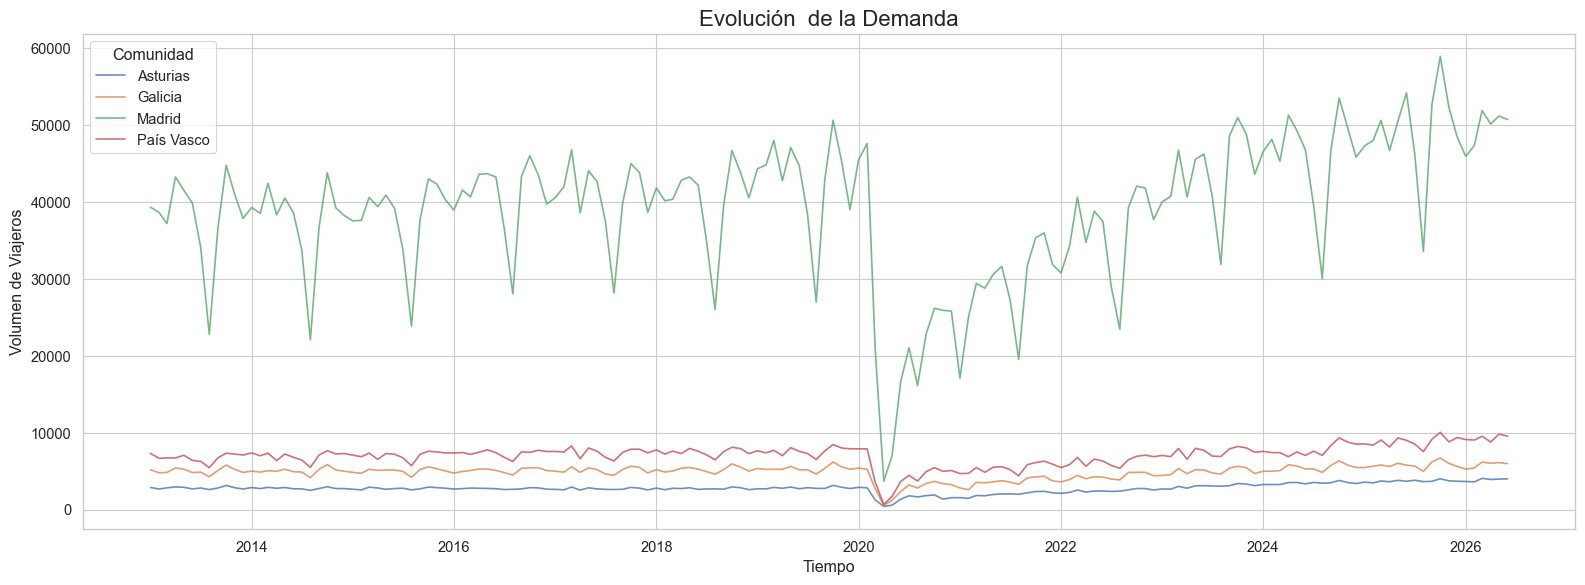

In [3]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f'--- Test ADF para: {name} ---')
    print(f'Estadístico ADF: {result[0]:.4f}')
    print(f'p-valor: {result[1]:.4f}')
    if result[1] <= 0.05:
        print("=> Rechazamos H0: La serie ES ESTACIONARIA (No tiene raíz unitaria).\n")
    else:
        print("=> No podemos rechazar H0: La serie NO ES ESTACIONARIA (Tiene raíz unitaria).\n")

# Ejecutamos el test para cada región
for region in regiones:
    serie_temporal = df[df['Comunidad'] == region].sort_values('fecha')['VIAJEROS']
    if not serie_temporal.empty:
        adf_test(serie_temporal, region)

# Gráfico de la evolución temporal superpuesta
plt.figure(figsize=(16, 6))
sns.lineplot(data=df, x='fecha', y='VIAJEROS', hue='Comunidad', alpha=0.8)
plt.title('Evolución  de la Demanda', fontsize=16)
plt.ylabel('Volumen de Viajeros')
plt.xlabel('Tiempo')
plt.tight_layout()
plt.show()

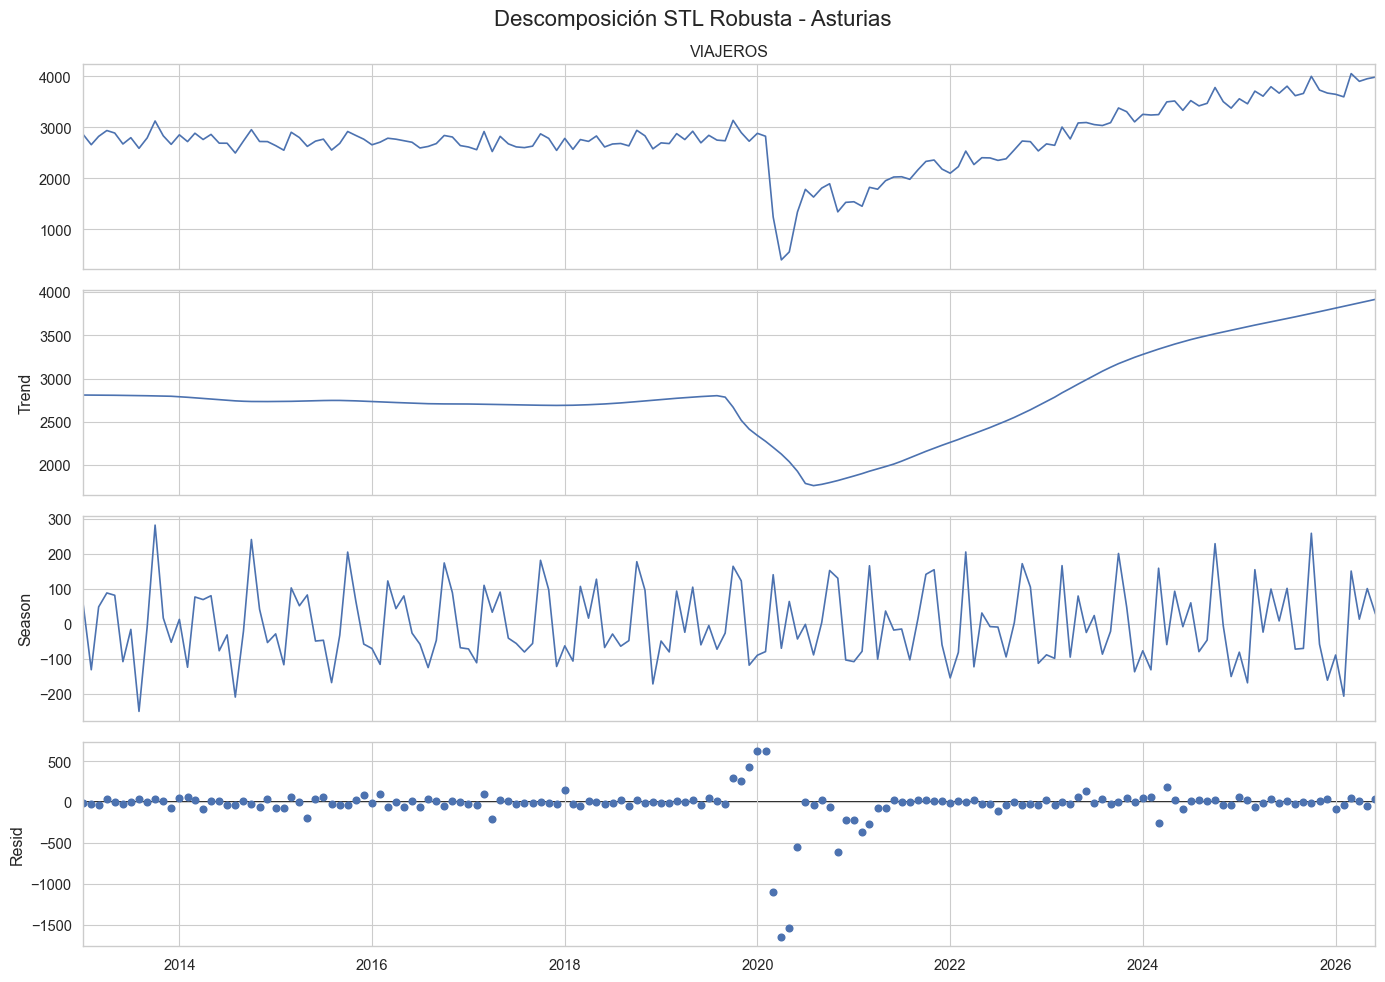

La estacionalidad explica el 3.10% de la varianza en Asturias.


In [3]:
from statsmodels.tsa.seasonal import STL

# Tomamos una región de ejemplo (puedes iterar sobre las demás)
region_analisis = 'Asturias'
serie_asturias = df[df['Comunidad'] == region_analisis].set_index('fecha').sort_index()['VIAJEROS']

# STL (Seasonal and Trend decomposition using Loess)
# period=12 porque la frecuencia es mensual
stl = STL(serie_asturias, period=12, robust=True)
res = stl.fit()

fig = res.plot()
fig.set_size_inches(14, 10)
fig.suptitle(f'Descomposición STL Robusta - {region_analisis}', fontsize=16)
plt.tight_layout()
plt.show()

# Varianza explicada por la estacionalidad
var_total = np.var(serie_asturias)
var_estacional = np.var(res.seasonal)
print(f"La estacionalidad explica el {(var_estacional/var_total)*100:.2f}% de la varianza en {region_analisis}.")

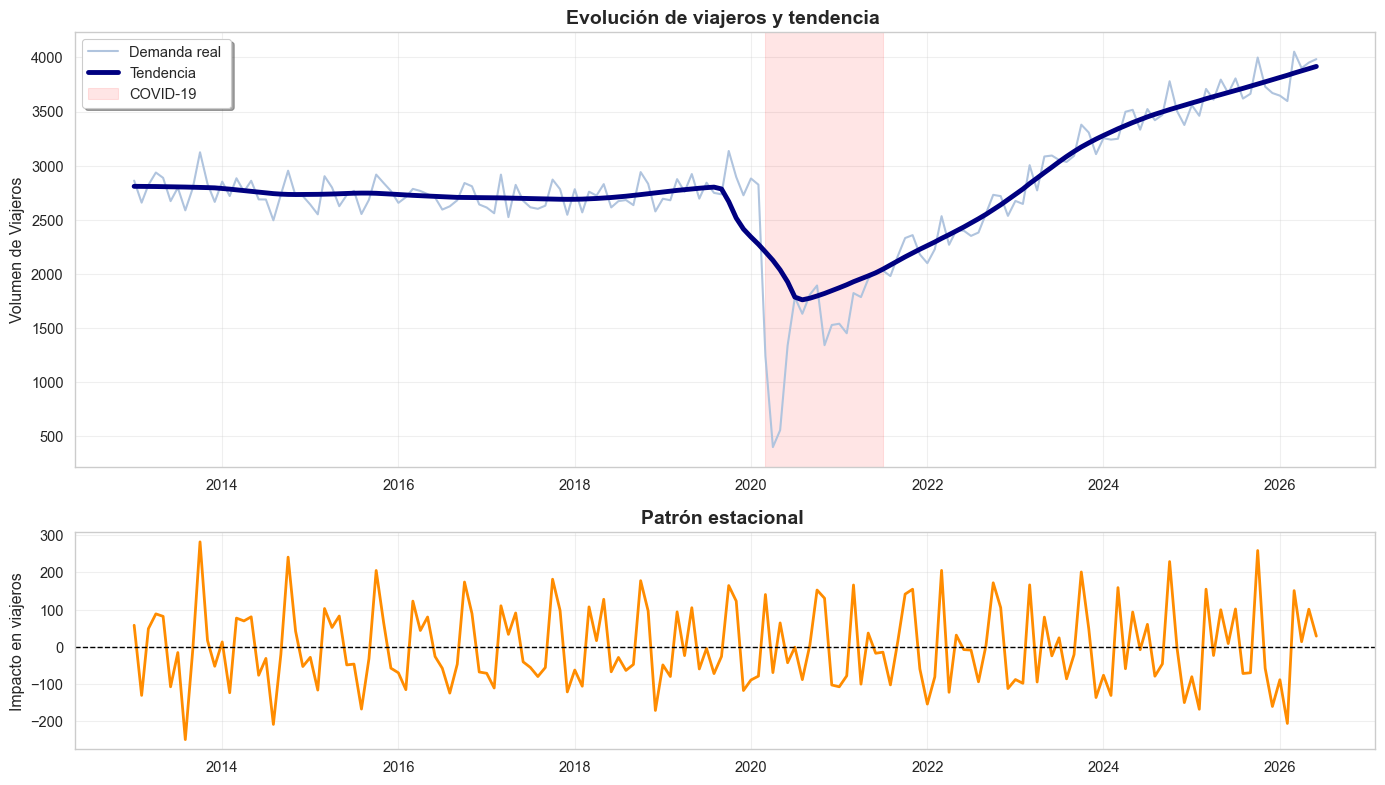

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.seasonal import STL

# 1. Filtramos los datos de una sola región y ponemos la fecha como índice temporal
# Cambia 'Asturias' por la región que prefieras mostrar como ejemplo en tu informe
df_region = df[df['Asturias'] == 1].copy()
df_region.set_index('fecha', inplace=True)

# 2. Calculamos la descomposición matemática (asumiendo estacionalidad de 12 meses)
stl = STL(df_region['VIAJEROS'], period=12, robust=True)
res = stl.fit()

# 3. Configuramos un lienzo limpio y profesional (2 paneles en lugar de 4)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [2, 1]})

# --- Panel Superior: Demanda vs Tendencia ---
ax1.plot(df_region.index, df_region['VIAJEROS'], color='lightsteelblue', label='Demanda real ', linewidth=1.5)
ax1.plot(df_region.index, res.trend, color='navy', label='Tendencia', linewidth=3.5)

# Sombrear la zona del COVID para justificar su eliminación
ax1.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2021-06-30'), 
            color='red', alpha=0.1, label='COVID-19')

ax1.set_title('Evolución de viajeros y tendencia ', fontsize=14, fontweight='bold')
ax1.set_ylabel('Volumen de Viajeros')
ax1.legend(loc='upper left', frameon=True, shadow=True)
ax1.grid(True, alpha=0.3)

# --- Panel Inferior: Estacionalidad ---
ax2.plot(df_region.index, res.seasonal, color='darkorange', linewidth=2)
ax2.axhline(0, color='black', linewidth=1, linestyle='--') # Línea base cero
ax2.set_title('Patrón estacional ', fontsize=14, fontweight='bold')
ax2.set_ylabel('Impacto en viajeros')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

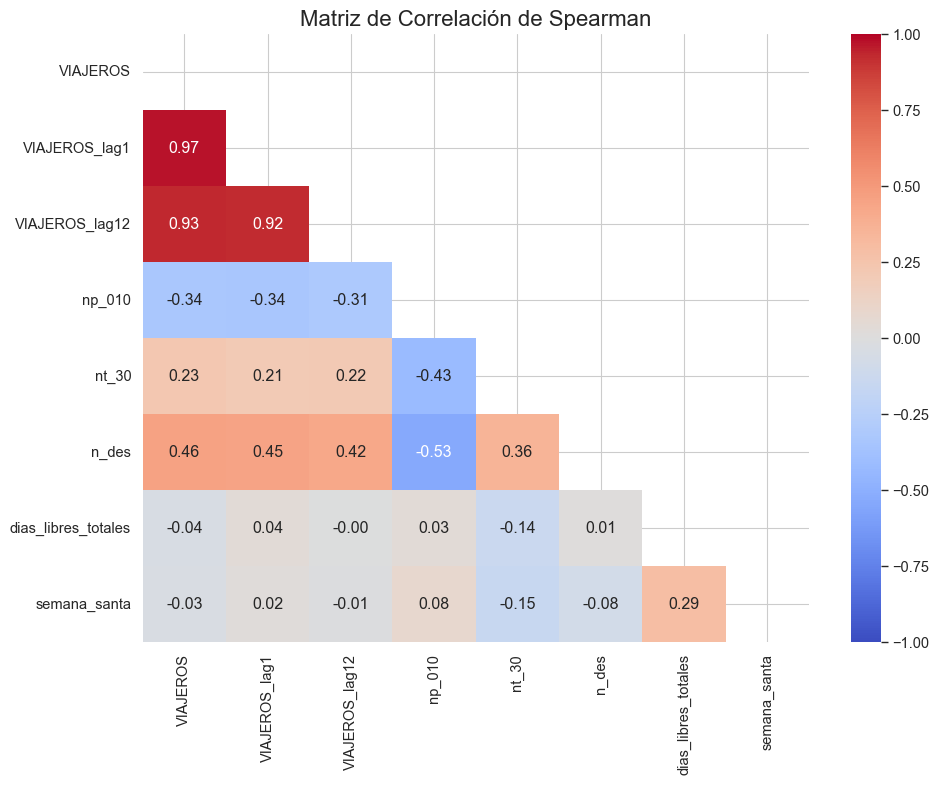

In [4]:
# Filtramos solo las variables numéricas y los predictores
cols_analisis = ['VIAJEROS', 'VIAJEROS_lag1', 'VIAJEROS_lag12', 
                 'np_010', 'nt_30', 'n_des', 'dias_libres_totales', 'semana_santa']

# Correlación de Spearman (No paramétrica)
corr_matrix = df[cols_analisis].corr(method='spearman')

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlación de Spearman', fontsize=16)
plt.tight_layout()
plt.show()

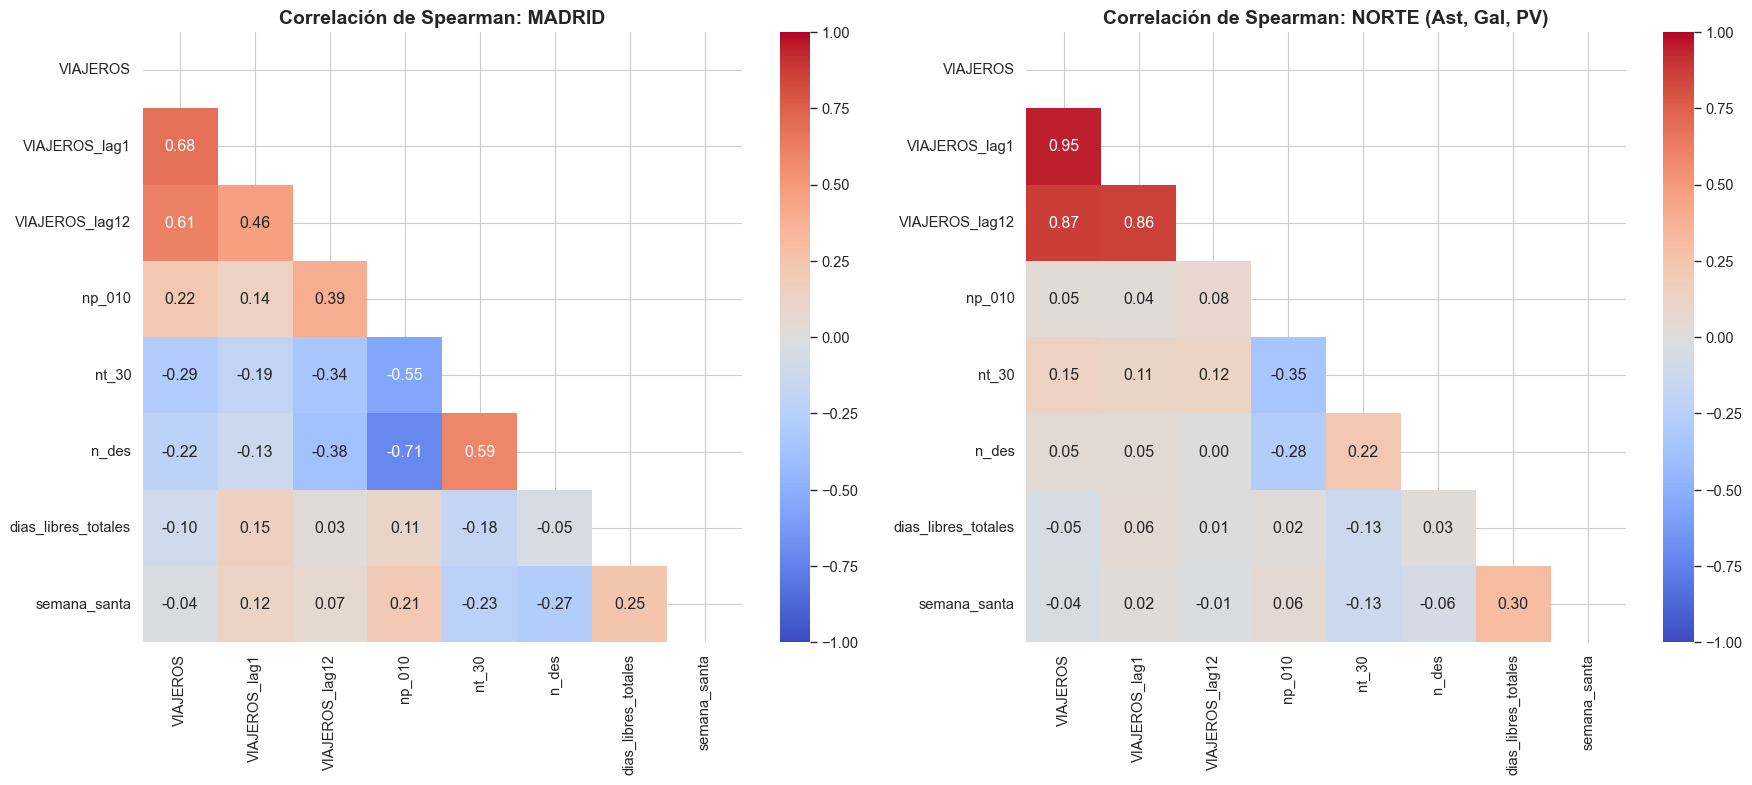

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Columnas a analizar
cols_analisis = ['VIAJEROS', 'VIAJEROS_lag1', 'VIAJEROS_lag12', 
                 'np_010', 'nt_30', 'n_des', 'dias_libres_totales', 'semana_santa']

# 1. Separar los datasets usando la columna One-Hot de Madrid
df_madrid = df[df['Madrid'] == 1]
df_norte = df[df['Madrid'] == 0] # Si no es Madrid, son las otras 3 del Norte

# 2. Calcular correlaciones por separado
corr_madrid = df_madrid[cols_analisis].corr(method='spearman')
corr_norte = df_norte[cols_analisis].corr(method='spearman')

# 3. Configurar el lienzo para dos gráficos
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Máscaras para tapar la parte superior duplicada del triángulo
mask_madrid = np.triu(np.ones_like(corr_madrid, dtype=bool))
mask_norte = np.triu(np.ones_like(corr_norte, dtype=bool))

# Gráfico 1: Madrid
sns.heatmap(corr_madrid, mask=mask_madrid, annot=True, cmap='coolwarm', 
            fmt=".2f", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Correlación de Spearman: MADRID', fontsize=14, fontweight='bold')

# Gráfico 2: Norte (Asturias, Galicia, País Vasco)
sns.heatmap(corr_norte, mask=mask_norte, annot=True, cmap='coolwarm', 
            fmt=".2f", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Correlación de Spearman: NORTE (Ast, Gal, PV)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Test de Mann-Whitney para Semana Santa: p-valor = 3.8837e-01


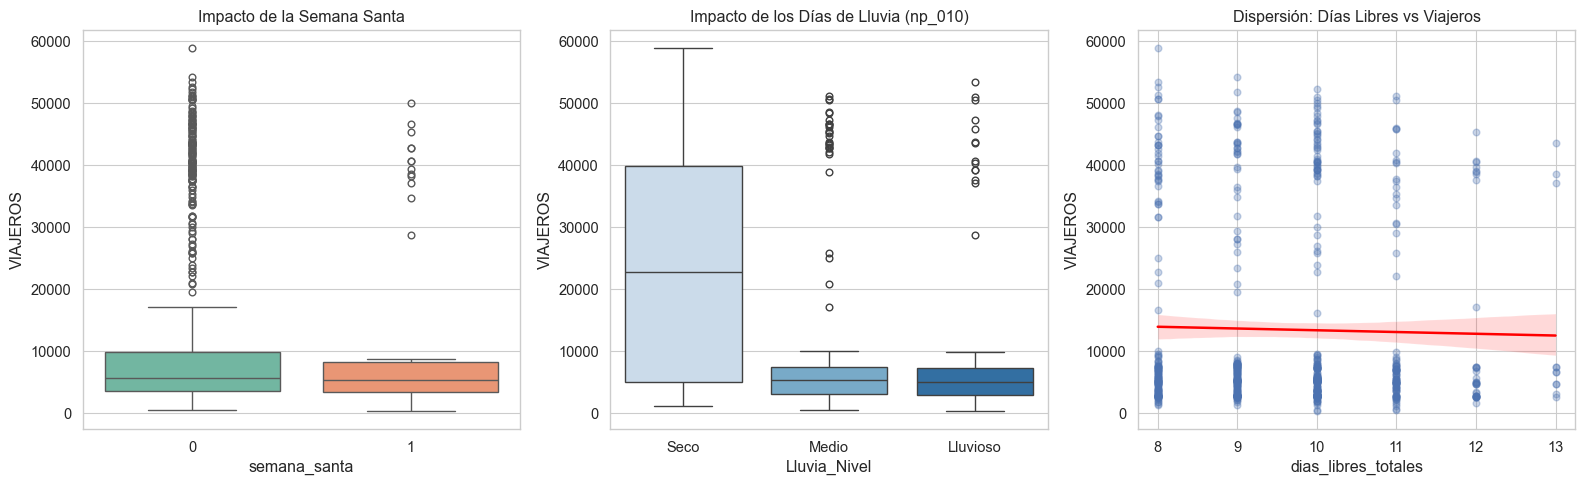

In [5]:
from scipy.stats import mannwhitneyu

# 1. IMPACTO DE SEMANA SANTA
con_ss = df[df['semana_santa'] == 1]['VIAJEROS']
sin_ss = df[df['semana_santa'] == 0]['VIAJEROS']

stat_ss, p_val_ss = mannwhitneyu(con_ss, sin_ss, alternative='two-sided')
print(f"Test de Mann-Whitney para Semana Santa: p-valor = {p_val_ss:.4e}")
if p_val_ss < 0.05:
    print("=> Diferencia estadísticamente significativa en meses con Semana Santa.")

plt.figure(figsize=(16, 5))

# Gráfico 1: Semana Santa
plt.subplot(1, 3, 1)
sns.boxplot(x='semana_santa', y='VIAJEROS', data=df, palette='Set2')
plt.title('Impacto de la Semana Santa')

# Gráfico 2: Efecto del Clima (Agrupado en cuantiles)
plt.subplot(1, 3, 2)
# Discretizamos los días de lluvia en 3 niveles (Seco, Normal, Lluvioso) para ver su impacto
df['Lluvia_Nivel'] = pd.qcut(df['np_010'], q=3, labels=['Seco', 'Medio', 'Lluvioso'])
sns.boxplot(x='Lluvia_Nivel', y='VIAJEROS', data=df, palette='Blues')
plt.title('Impacto de los Días de Lluvia (np_010)')

# Gráfico 3: Días Libres (Regresión Lineal Simple para ver la pendiente)
plt.subplot(1, 3, 3)
sns.regplot(x='dias_libres_totales', y='VIAJEROS', data=df, 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Dispersión: Días Libres vs Viajeros')

plt.tight_layout()
plt.show()

# Limpiamos la columna auxiliar
df = df.drop(columns=['Lluvia_Nivel'])

1. La inercia lo es (casi) todo (El poder del Lag)
La conclusión: Si quieres saber cuánta gente viajará en ALSA en agosto de 2026, el mejor chivato es mirar cuánta viajó el mes pasado (julio 2026) y el mismo mes del año anterior (agosto 2025).

Implicación para el modelo: Estas dos variables (lag1 y lag12) explican más del 90% del comportamiento de tus viajeros. Son el "motor" del algoritmo. El modelo será, en el fondo, un reconocedor de patrones históricos.

2. El clima es un "acelerador" secundario muy válido
La conclusión: El buen tiempo (días despejados) invita a viajar de forma más agresiva que lo que la lluvia (días con precipitación) desanima a hacerlo.

Implicación para el modelo: Las variables climáticas nos van a servir para afinar ese 10% de varianza que la historia no puede explicar. Le dirán al modelo: "Oye, el histórico dice que toca vender 3.000 billetes, pero como este mes está siendo súper soleado, súbele 200 más".

3. Las variables de calendario son "trampas mensuales"
La conclusión: Contar festivos o marcar la Semana Santa a nivel mensual no sirve. Un mes tiene 30 días; que haya un puente de 3 días se "diluye" en la suma total mensual, y el efecto frontera (Semana Santa cayendo entre marzo y abril) confunde a las matemáticas.

Implicación para el modelo: Le daremos estas variables al algoritmo (sobre todo XGBoost, que es muy listo filtrando basura), pero no esperes que el modelo se apoye mucho en ellas. Las ignorará en favor de los Lags y el clima.

4. El "Agujero Negro" del COVID-19
La conclusión: La gráfica de descomposición STL mostró que la caída de pasajeros en 2020 y 2021 fue un shock anómalo (un cisne negro), no un patrón natural de ALSA.

Implicación para el modelo (CRÍTICA): Si metemos los meses de confinamiento duro en el entrenamiento, el algoritmo pensará que, de vez en cuando, los viajeros pueden caer a cero por causas naturales. Tendremos que borrar el periodo aprox. de marzo 2020 a junio 2021 antes de entrenar, o el modelo se volverá pesimista e impreciso.

5. Madrid aplasta a las regiones del norte (Problema de Escala)
La conclusión: Madrid mueve entre 30.000 y 60.000 viajeros, mientras que Asturias, Galicia y País Vasco se mueven en apenas un par de miles.

Implicación para el modelo (CRÍTICA): Si entrenamos un único modelo para predecir todas las regiones a la vez tal y como están, el algoritmo se obsesionará con acertar en Madrid (porque fallar ahí supone un error matemático enorme) y descuidará por completo las predicciones del Norte. Tendremos que aplicar logaritmos o entrenar a Madrid por separado.